# Topic Modelling About MBG

> Perbandingan Latent Dirichlet Allocation (LDA) dan Non-negative Matrix Factorization (NMF) untuk Identifikasi Topik Opini Publik terhadap Program Makan Bergizi Gratis (MBG) pada Komentar TikTok dan YouTube

This notebook provides a complete wrapper for all operations pipeline for MBG-related social media comments.

## Pipeline Stages:
1. **Data Collection** - Scraping from TikTok and YouTube (using existing data)
2. **EDA & Data Loading** - Exploratory data analysis
3. **Preprocessing** - Text cleaning, normalization, and filtering
4. **Topic Modeling** - LDA and NMF for topic discovery
5. **Visualization** - Topic and data visualization
6. **Evaluation** - Model evaluation and metrics

**Note:** This notebook uses existing scrapped data and does not run the data collection stage.

In [29]:
# Import all necessary libraries and pipeline modules
import sys
import os
import logging
import json
import pickle
import warnings

# Data manipulation
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Import pipeline modules directly
import importlib.util

warnings.filterwarnings('ignore')

# Add parent directory to path for imports
project_root = Path().absolute()
sys.path.insert(0, str(project_root))

# Load 01_collect_data module
spec1 = importlib.util.spec_from_file_location("collect_data", str(project_root / "pipelines" / "01_collect_data.py"))
collect_data = importlib.util.module_from_spec(spec1)
spec1.loader.exec_module(collect_data)

# Load 02_preprocess_data module
spec2 = importlib.util.spec_from_file_location("preprocess_data", str(project_root / "pipelines" / "02_preprocess_data.py"))
preprocess_data = importlib.util.module_from_spec(spec2)
spec2.loader.exec_module(preprocess_data)

# Load 03_prepare_labeling module
spec3 = importlib.util.spec_from_file_location("prepare_labeling", str(project_root / "pipelines" / "03_prepare_labeling.py"))
prepare_labeling = importlib.util.module_from_spec(spec3)
spec3.loader.exec_module(prepare_labeling)

# Load 04_topic_modeling module
spec4 = importlib.util.spec_from_file_location("topic_modeling", str(project_root / "pipelines" / "04_topic_modeling.py"))
topic_modeling = importlib.util.module_from_spec(spec4)
spec4.loader.exec_module(topic_modeling)

# Load 05_evaluation module
spec5 = importlib.util.spec_from_file_location("evaluation", str(project_root / "pipelines" / "05_evaluation.py"))
evaluation = importlib.util.module_from_spec(spec5)
spec5.loader.exec_module(evaluation)

# Assign classes to variables for easier access
TiktokScraper = collect_data.TiktokScraper
YoutubeScraper = collect_data.YoutubeScraper
BasePreprocessor = preprocess_data.BasePreprocessor
TiktokPreprocessor = preprocess_data.TiktokPreprocessor
YoutubePreprocessor = preprocess_data.YoutubePreprocessor
DataPreprocessor = preprocess_data.DataPreprocessor
LabelingPreparator = prepare_labeling.LabelingPreparator
TopicModelingPipeline = topic_modeling.TopicModelingPipeline
TopicModelEvaluator = evaluation.TopicModelEvaluator
TOPIC_STOPWORDS = topic_modeling.TOPIC_STOPWORDS

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set up matplotlib for better visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports loaded successfully")
print(f"✓ Working directory: {os.getcwd()}")
print(f"✓ Project root: {project_root}")
print(f"✓ Data directory: {project_root / 'data'}")

✓ All imports loaded successfully
✓ Working directory: d:\python\stance-classification
✓ Project root: d:\python\stance-classification
✓ Data directory: d:\python\stance-classification\data


## 1. Data Collection (Using Existing Data)

**Note:** This notebook uses existing scrapped data from `data/scrapped/`. To collect new data, run the collection scripts separately.

In [11]:
# Check available scrapped data
data_dir = project_root / "data"
scrapped_dir = data_dir / "scrapped"

print("Checking latest scrapped data files:")
print("=" * 50)

if scrapped_dir.exists():
    tiktok_files = list(scrapped_dir.glob("tiktok_comments_raw*.csv"))
    youtube_files = list(scrapped_dir.glob("youtube_comments_raw*.csv"))
    
    # Target variables for the latest files
    latest_tiktok_file = None
    latest_youtube_file = None
    
    if tiktok_files:
        # Sorted will put higher increments at the end (e.g., _1, _2, _3)
        latest_tiktok_file = sorted(tiktok_files)[-1]
        size_mb = latest_tiktok_file.stat().st_size / (1024 * 1024)
        print(f"Latest TikTok file found: {latest_tiktok_file.name} ({size_mb:.2f} MB)")
    else:
        print("No TikTok files found.")
        
    if youtube_files:
        # Get the last element from the sorted list
        latest_youtube_file = sorted(youtube_files)[-1]
        size_mb = latest_youtube_file.stat().st_size / (1024 * 1024)
        print(f"Latest YouTube file found: {latest_youtube_file.name} ({size_mb:.2f} MB)")
    else:
        print("No YouTube files found.")

else:
    print("Scrapped data directory does not exist.")

Checking latest scrapped data files:
Latest TikTok file found: tiktok_comments_raw_1.csv (2.99 MB)
Latest YouTube file found: youtube_comments_raw.csv (0.32 MB)


## 2. EDA & Data Loading

Load and explore the existing scrapped data from both platforms.

In [12]:
# Load raw data using the preprocessor classes
preprocessor = DataPreprocessor(data_dir=str(data_dir))

# Load raw data from both platforms
try:
    df_raw = preprocessor.load_raw_data()
    print(f"✓ Successfully loaded {len(df_raw)} comments")
    print(f"\nPlatform distribution:")
    print(df_raw['source'].value_counts())
    print(f"\nData columns: {list(df_raw.columns)}")
    print(f"\nFirst few rows:")
    display(df_raw.head())
except FileNotFoundError as e:
    print(f"✗ Error loading data: {e}")
    print("Please ensure scrapped data exists in data/scrapped/")

2026-06-18 17:52:51,230 - INFO - Loaded 4000 TikTok comments from d:\python\stance-classification\data\scrapped\tiktok_comments_raw_1.csv
2026-06-18 17:52:51,231 - INFO - Loaded TikTok data: 4000 comments
2026-06-18 17:52:51,238 - INFO - Loaded 1283 YouTube comments from d:\python\stance-classification\data\scrapped\youtube_comments_raw.csv
2026-06-18 17:52:51,238 - INFO - Loaded YouTube data: 1283 comments
2026-06-18 17:52:51,240 - INFO - Combined total: 5283 comments


✓ Successfully loaded 5283 comments

Platform distribution:
source
tiktok     4000
youtube    1283
Name: count, dtype: int64

Data columns: ['created_at', 'raw_text', 'likes_count', 'reply_count', 'source']

First few rows:


,created_at,raw_text,likes_count,reply_count,source
0,2026-03-22T22:25:43.000Z,siapa yg setuju MBG distop?,3942,69.0,tiktok
1,2026-03-22T14:01:13.000Z,"Susah sekali bapak Presiden ini di kritiknya, ...",2816,68.0,tiktok
2,2026-03-22T13:19:14.000Z,hentikan aj pak\nmending dialihkan ke program ...,1999,60.0,tiktok
3,2026-03-22T15:12:08.000Z,Kepala keras sekali,421,29.0,tiktok
4,2026-03-22T14:54:57.000Z,cukup satu periode,1022,56.0,tiktok


Basic Statistics:
Total comments: 5283
Average text length: 82.15 characters
Average word count: 13.36 words
Average likes: 4.52
Average replies: 0.40


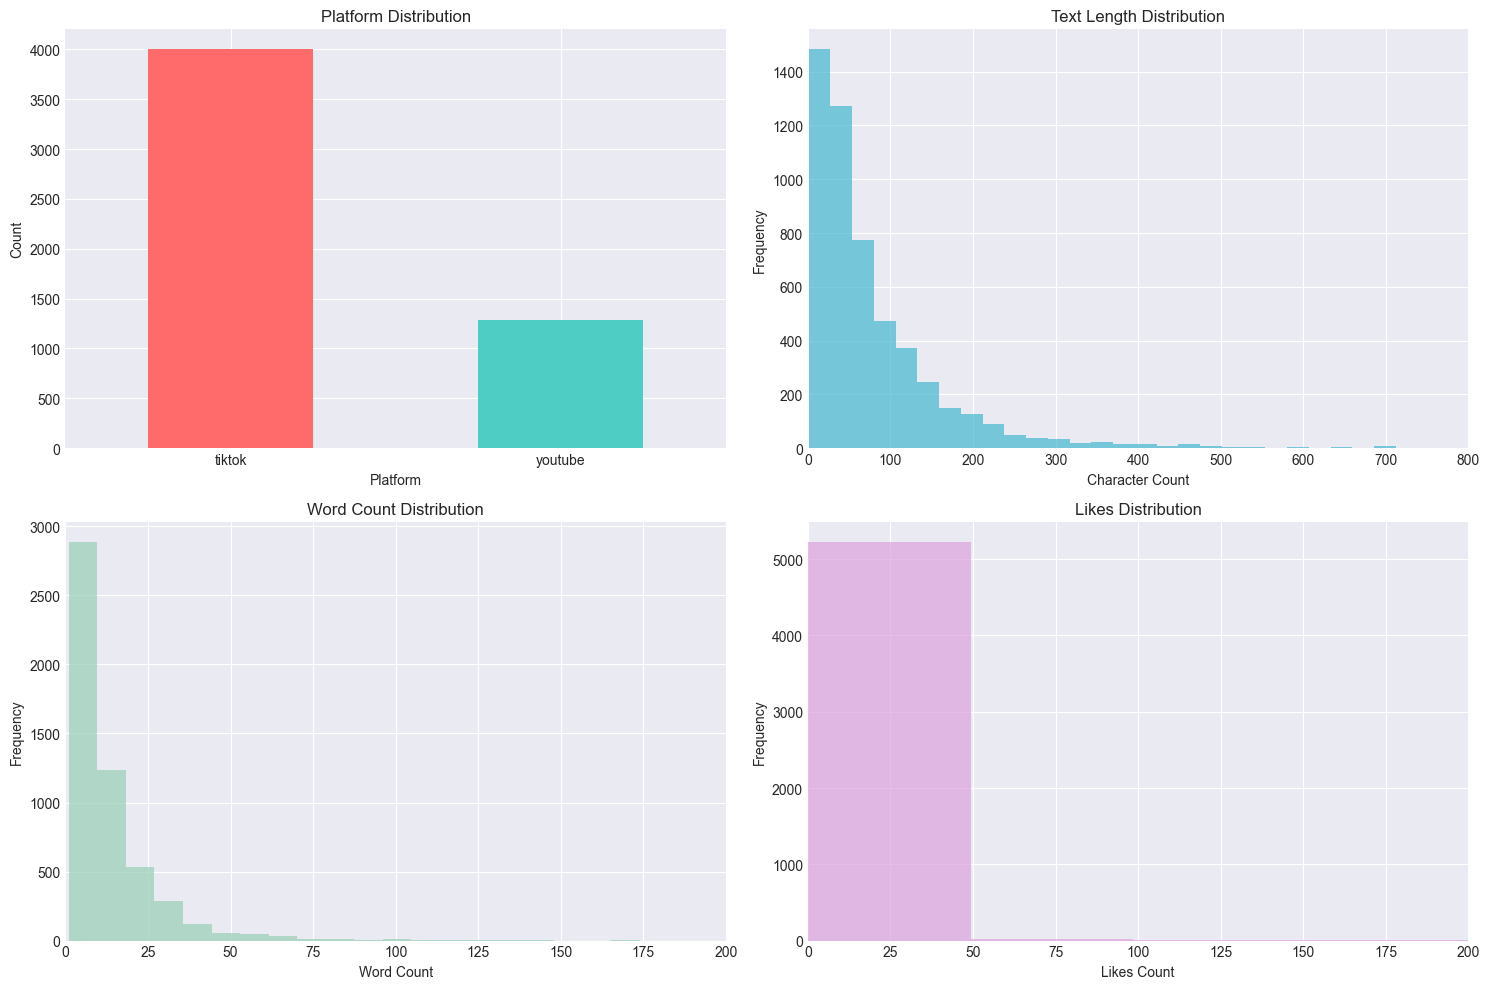


Platform-specific Statistics:

TIKTOK:
  Comments: 4000
  Avg text length: 66.92
  Avg word count: 11.22
  Avg likes: 4.95
  Avg replies: 0.33

YOUTUBE:
  Comments: 1283
  Avg text length: 129.48
  Avg word count: 20.01
  Avg likes: 3.15
  Avg replies: 0.53


In [27]:
# EDA: Basic statistics and visualizations
if 'df_raw' in locals() and not df_raw.empty:
    # Basic statistics
    print("Basic Statistics:")
    print("=" * 50)
    print(f"Total comments: {len(df_raw)}")
    print(f"Average text length: {df_raw['raw_text'].str.len().mean():.2f} characters")
    print(f"Average word count: {df_raw['raw_text'].str.split().str.len().mean():.2f} words")
    print(f"Average likes: {df_raw['likes_count'].mean():.2f}")
    print(f"Average replies: {df_raw['reply_count'].mean():.2f}")
    
    # Platform distribution visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Platform distribution
    df_raw['source'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4'])
    axes[0, 0].set_title('Platform Distribution')
    axes[0, 0].set_xlabel('Platform')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=0)
    
    # Text length distribution
    df_raw['raw_text'].str.len().hist(bins=80, ax=axes[0, 1], color='#45B7D1', alpha=0.7)
    axes[0, 1].set_title('Text Length Distribution')
    axes[0, 1].set_xlabel('Character Count')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_xlim(0, 800)
    
    # Word count distribution
    df_raw['raw_text'].str.split().str.len().hist(bins=80, ax=axes[1, 0], color='#96CEB4', alpha=0.7)
    axes[1, 0].set_title('Word Count Distribution')
    axes[1, 0].set_xlabel('Word Count')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_xlim(0, 200)
    
    # Likes distribution
    df_raw['likes_count'].hist(bins=80, ax=axes[1, 1], color='#DDA0DD', alpha=0.7)
    axes[1, 1].set_title('Likes Distribution')
    axes[1, 1].set_xlabel('Likes Count')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_xlim(0, 200)
    
    plt.tight_layout()
    plt.show()
    
    # Platform-specific statistics
    print("\nPlatform-specific Statistics:")
    print("=" * 50)
    for platform in df_raw['source'].unique():
        platform_data = df_raw[df_raw['source'] == platform]
        print(f"\n{platform.upper()}:")
        print(f"  Comments: {len(platform_data)}")
        print(f"  Avg text length: {platform_data['raw_text'].str.len().mean():.2f}")
        print(f"  Avg word count: {platform_data['raw_text'].str.split().str.len().mean():.2f}")
        print(f"  Avg likes: {platform_data['likes_count'].mean():.2f}")
        print(f"  Avg replies: {platform_data['reply_count'].mean():.2f}")
else:
    print("No data loaded. Please run the previous cell first.")

## 3. Preprocessing

Clean and normalize the text data using the preprocessing pipeline.

In [14]:
# Run preprocessing pipeline
if 'df_raw' in locals() and not df_raw.empty:
    print("Starting preprocessing pipeline...")
    print("=" * 50)
    
    # Preprocess the dataset
    df_processed = preprocessor.preprocess_dataset(df_raw)
    
    print(f"\n✓ Preprocessing completed")
    print(f"✓ Original comments: {len(df_raw)}")
    print(f"✓ After filtering: {len(df_processed)}")
    print(f"✓ Removed: {len(df_raw) - len(df_processed)} spam/empty comments")
    
    # Analyze data quality
    analysis = preprocessor.analyze_data_quality(df_processed)
    
    print(f"\nData Quality Analysis:")
    print("=" * 50)
    print(f"Overall statistics:")
    print(f"  Total comments: {analysis['overall']['total_comments']}")
    print(f"  Platforms: {analysis['overall']['platforms']}")
    print(f"  Avg text length: {analysis['overall']['avg_text_length']:.2f}")
    print(f"  Avg word count: {analysis['overall']['avg_word_count']:.2f}")
    
    # Display processed data
    print(f"\nProcessed data sample:")
    display(df_processed[['raw_text', 'clean_text', 'final_text', 'source', 'is_spam']].head())
    
    # Save processed data
    preprocessor.save_processed_data(df_processed, analysis)
    print(f"\n✓ Processed data saved to {preprocessor.data_dir}")
else:
    print("No raw data loaded. Please run the data loading cells first.")

2026-06-18 17:52:51,800 - INFO - Starting combined data preprocessing...


Starting preprocessing pipeline...


2026-06-18 17:52:52,207 - INFO - Filtered out 1672 spam/empty comments
2026-06-18 17:52:52,208 - INFO - Remaining comments: 3611



✓ Preprocessing completed
✓ Original comments: 5283
✓ After filtering: 3611
✓ Removed: 1672 spam/empty comments

Data Quality Analysis:
Overall statistics:
  Total comments: 3611
  Platforms: ['tiktok', 'youtube']
  Avg text length: 84.57
  Avg word count: 13.85

Processed data sample:


,raw_text,clean_text,final_text,source,is_spam
0,siapa yg setuju MBG distop?,setuju makan bergizi gratis distop?,setuju makan bergizi gratis distop?,tiktok,False
1,"Susah sekali bapak Presiden ini di kritiknya, ...","susah presiden kritiknya, masyarakat tokoh nas...","susah presiden kritiknya, masyarakat tokoh nas...",tiktok,False
2,hentikan aj pak\nmending dialihkan ke program ...,hentikan mending dialihkan program beasiswa ku...,hentikan mending dialihkan program beasiswa ku...,tiktok,False
3,Kepala keras sekali,kepala keras,kepala keras,tiktok,False
4,cukup satu periode,periode,periode,tiktok,False


2026-06-18 17:52:52,287 - INFO - Data saved to d:\python\stance-classification\data\preprocessed\comments_processed_5.csv
2026-06-18 17:52:52,288 - INFO - Total records: 3611
2026-06-18 17:52:52,293 - INFO - Data saved to d:\python\stance-classification\data\preprocessed\preprocessing_analysis_5.csv
2026-06-18 17:52:52,295 - INFO - Total records: 1
2026-06-18 17:52:52,297 - INFO - Saved detailed analysis to d:\python\stance-classification\data\preprocessed\preprocessing_analysis_detailed.json



✓ Processed data saved to d:\python\stance-classification\data\preprocessed


## 4. Topic Modeling

Apply LDA and NMF topic modeling to discover themes in the comments.

In [15]:
# Configure topic modeling parameters
N_TOPICS = 5
N_WORDS = 10
RANDOM_STATE = 42

print(f"Topic Modeling Configuration:")
print("=" * 50)
print(f"Number of topics: {N_TOPICS}")
print(f"Top words per topic: {N_WORDS}")
print(f"Random state: {RANDOM_STATE}")

Topic Modeling Configuration:
Number of topics: 5
Top words per topic: 10
Random state: 42


In [16]:
# Run topic modeling pipeline
topic_pipeline = TopicModelingPipeline(
    data_dir=str(data_dir),
    n_topics=N_TOPICS,
    n_words=N_WORDS,
    random_state=RANDOM_STATE
)

print("Running topic modeling pipeline...")
print("=" * 50)

try:
    results = topic_pipeline.run()
    print(f"\n✓ Topic modeling completed successfully")
    print(f"✓ Records processed: {results['records']}")
    print(f"✓ Topics saved to: {results['topics_file']}")
    print(f"✓ Document topics saved to: {results['document_topics_file']}")
except Exception as e:
    print(f"✗ Error during topic modeling: {e}")
    print("Please ensure preprocessed data exists in data/preprocessed/")

2026-06-18 17:52:52,353 - INFO - Loaded 3611 records from d:\python\stance-classification\data\preprocessed\comments_processed_5.csv
2026-06-18 17:52:52,368 - INFO - Using 3611 non-empty comments for topic modeling
2026-06-18 17:52:52,370 - INFO - Source distribution: {'tiktok': 2694, 'youtube': 917}


Running topic modeling pipeline...


2026-06-18 17:52:52,557 - INFO - Count matrix shape: (3611, 1085)
2026-06-18 17:52:52,558 - INFO - TF-IDF matrix shape: (3611, 1085)
2026-06-18 17:52:58,303 - INFO - Saved topics and document topics
2026-06-18 17:52:58,312 - INFO - Saved models and vectorizers
2026-06-18 17:52:58,313 - INFO - Topic modeling completed successfully



✓ Topic modeling completed successfully
✓ Records processed: 3611
✓ Topics saved to: d:\python\stance-classification\data\topic_modeling\topics.csv
✓ Document topics saved to: d:\python\stance-classification\data\topic_modeling\document_topics.csv


## 5. Visualization

Load and visualize the topic modeling results.

In [17]:
# Load topic modeling results for visualization
topics_file = data_dir / "topic_modeling" / "topics.csv"
doc_topics_file = data_dir / "topic_modeling" / "document_topics.csv"

if topics_file.exists() and doc_topics_file.exists():
    df_topics = pd.read_csv(topics_file)
    df_doc_topics = pd.read_csv(doc_topics_file)
    
    print("✓ Topic modeling results loaded")
    print(f"✓ Topics: {len(df_topics)}")
    print(f"✓ Document assignments: {len(df_doc_topics)}")
    
    # Display topics by model
    print("\n" + "=" * 50)
    print("LDA Topics:")
    print("=" * 50)
    lda_topics = df_topics[df_topics['model'] == 'lda']
    for _, row in lda_topics.iterrows():
        print(f"\nTopic {row['topic_id']} ({row['topic_label']}):")
        print(f"  Top words: {row['top_words']}")
    
    print("\n" + "=" * 50)
    print("NMF Topics:")
    print("=" * 50)
    nmf_topics = df_topics[df_topics['model'] == 'nmf']
    for _, row in nmf_topics.iterrows():
        print(f"\nTopic {row['topic_id']} ({row['topic_label']}):")
        print(f"  Top words: {row['top_words']}")
    
    # Display document topic distribution
    print("\n" + "=" * 50)
    print("Document Topic Distribution:")
    print("=" * 50)
    topic_dist = df_doc_topics.groupby(['model', 'dominant_topic']).size().unstack(fill_value=0)
    print(topic_dist)
else:
    print("✗ Topic modeling results not found. Please run the topic modeling cell first.")

✓ Topic modeling results loaded
✓ Topics: 10
✓ Document assignments: 7222

LDA Topics:

Topic 0 (Penghentian atau evaluasi program):
  Top words: rakyat, negara, stop, anggaran, benar, uang, presiden, bagus, jangan, bukan

Topic 1 (Anak, sekolah, dan manfaat gizi):
  Top words: anak, baik, lapangan, indonesia, presiden, prabowo, masyarakat, kasih, gizi, sehat

Topic 2 (Anak, sekolah, dan manfaat gizi):
  Top words: anak, sekolah, prabowo, desa, daerah, stunting, anak anak, ekonomi, makanan, lanjutkan

Topic 3 (Implementasi dapur, menu, dan sekolah):
  Top words: dikorupsi, sekolah, setuju, menu, guru, dana, uang, dapur, mending, langsung

Topic 4 (Korupsi dan penyalahgunaan program):
  Top words: korupsi, presiden, ladang, periode, jangan, kepala, uang, ladang korupsi, keras, bagus

NMF Topics:

Topic 0 (Korupsi dan penyalahgunaan program):
  Top words: korupsi, ladang, ladang korupsi, uang, uang korupsi, lahan, bukan, lahan korupsi, gimana, sarang korupsi

Topic 1 (Anak, sekolah, dan 

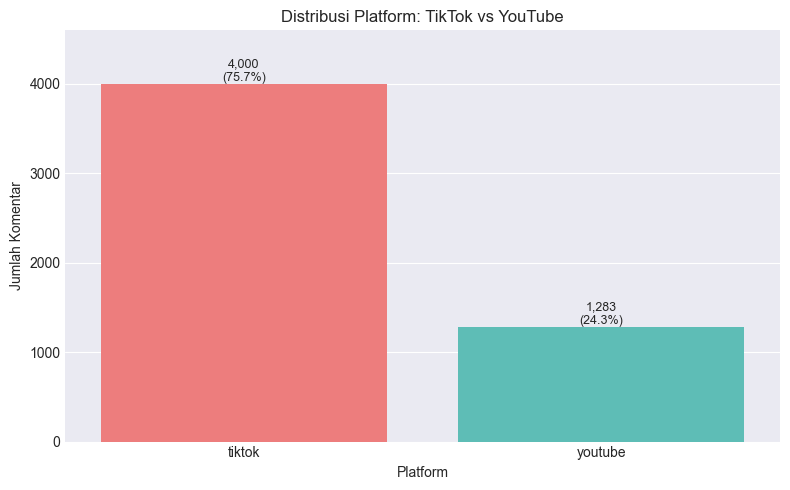

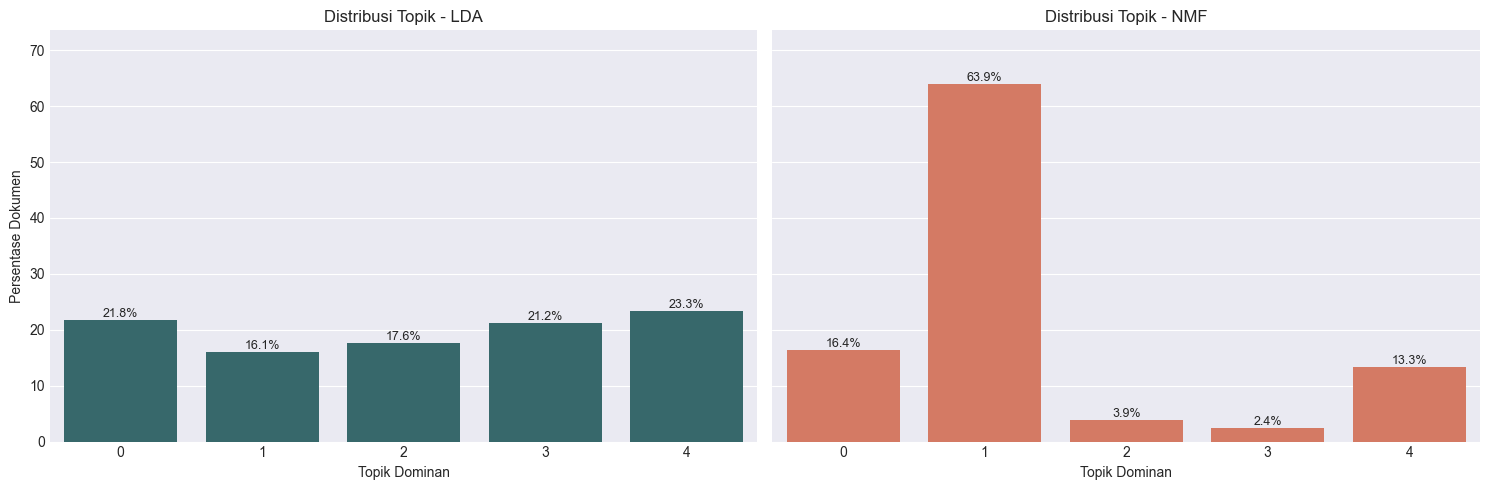

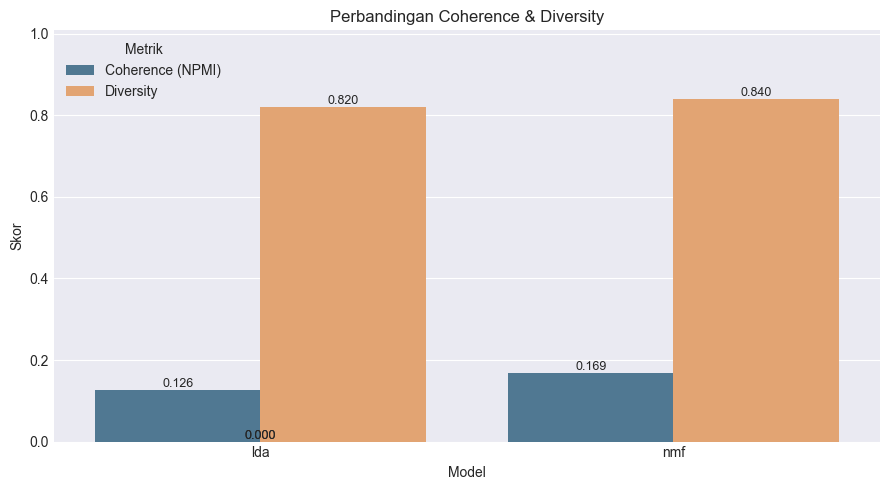

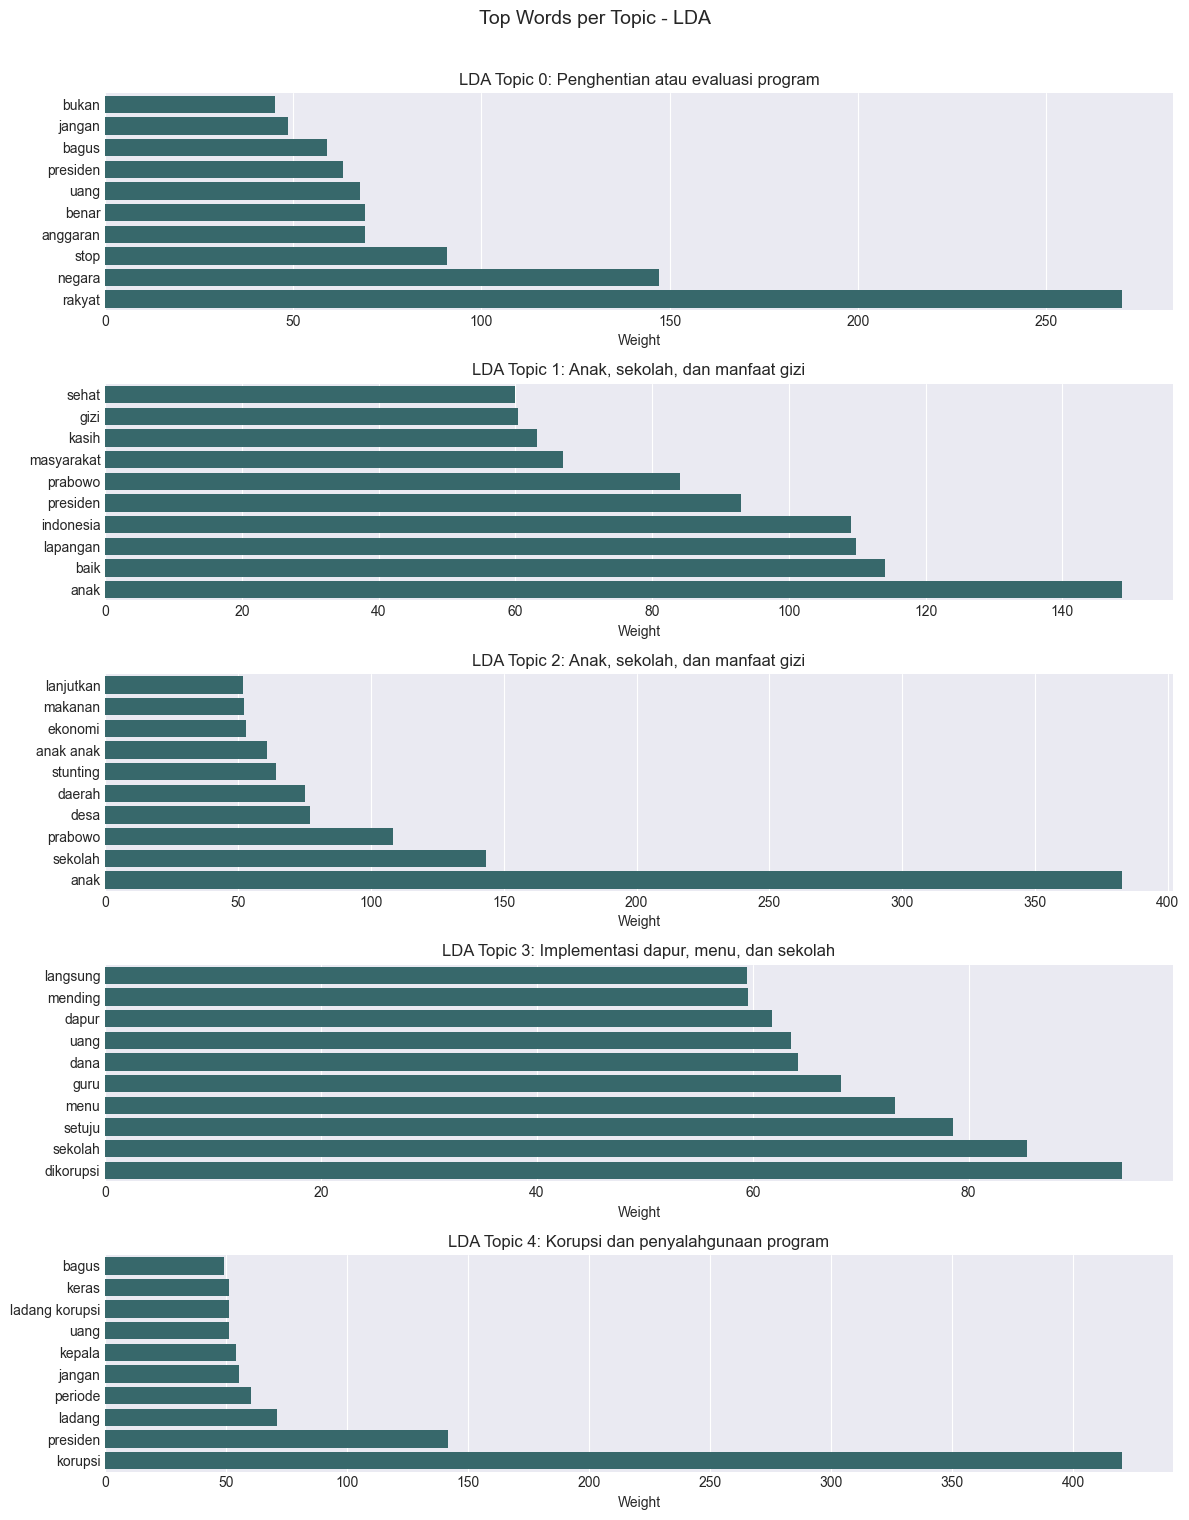

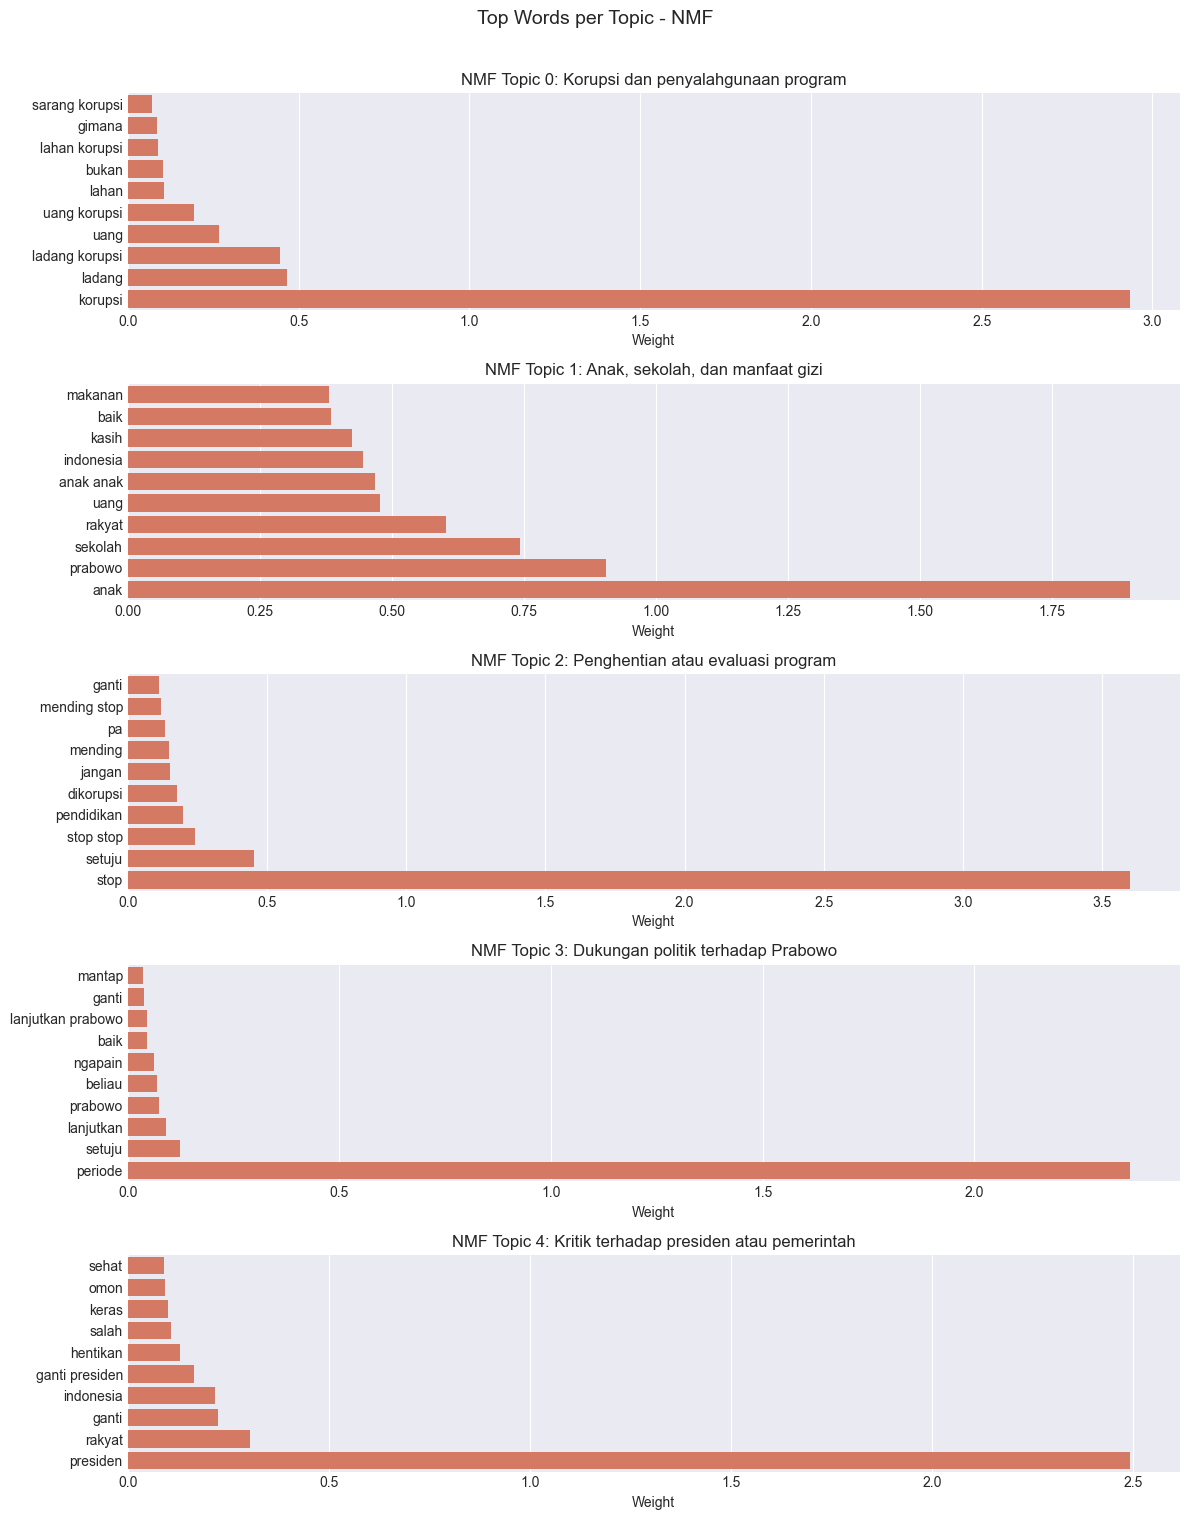

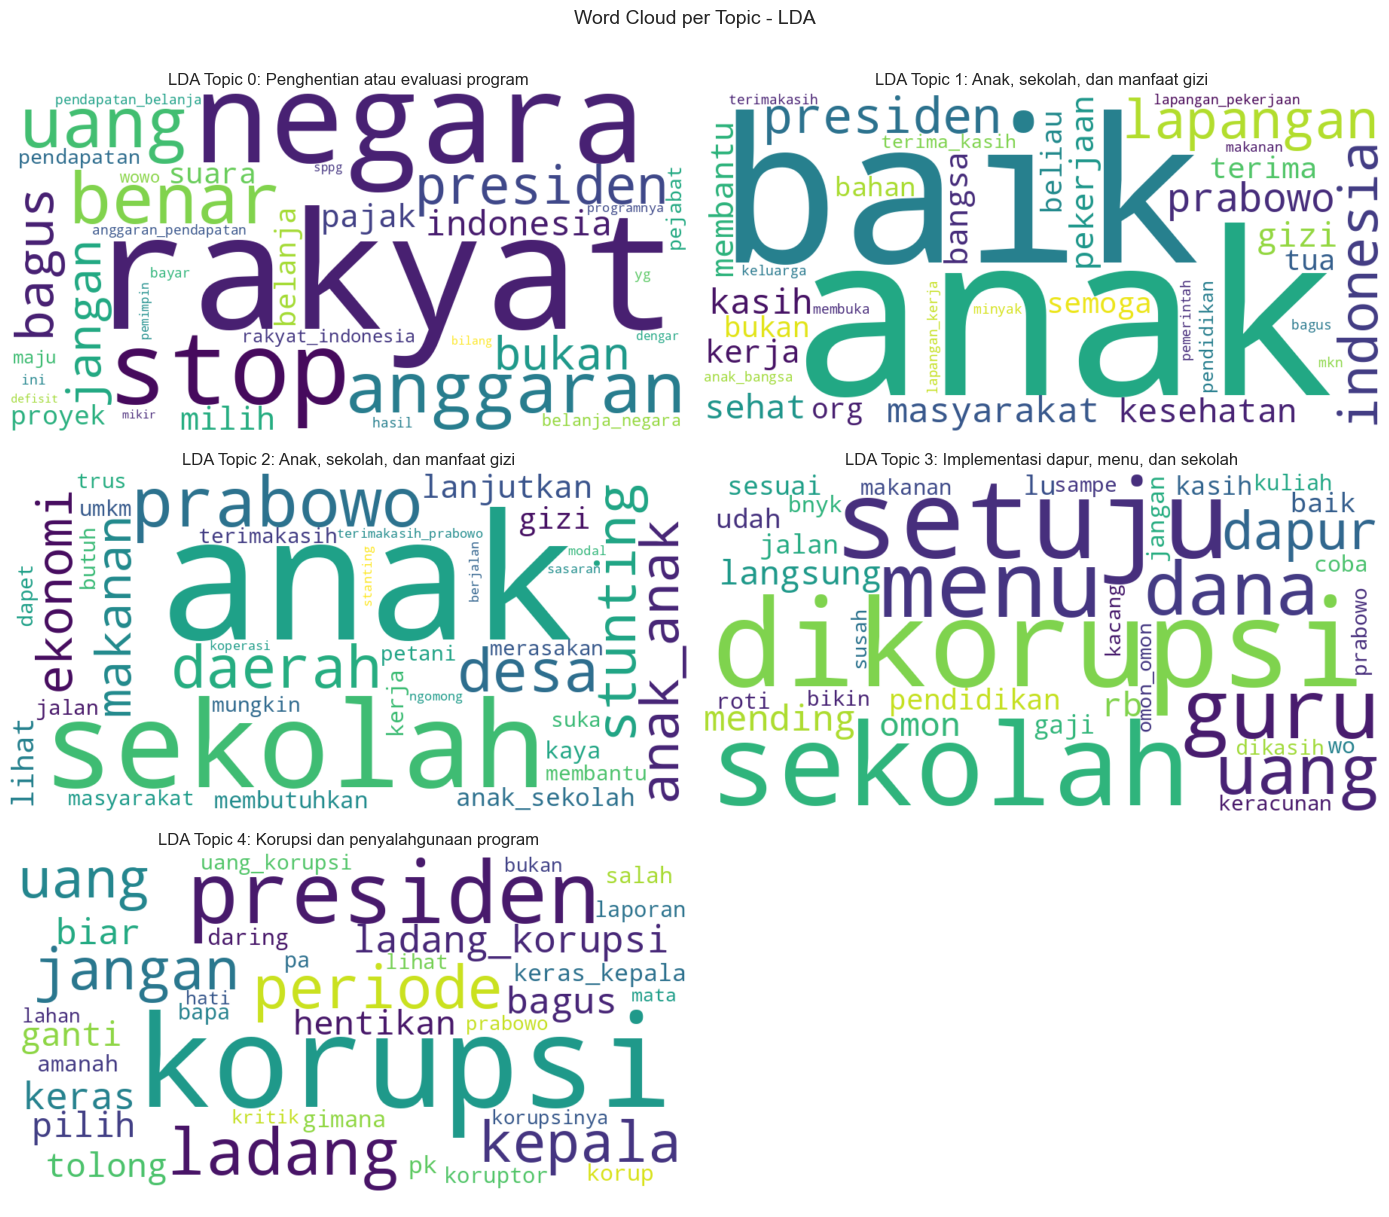

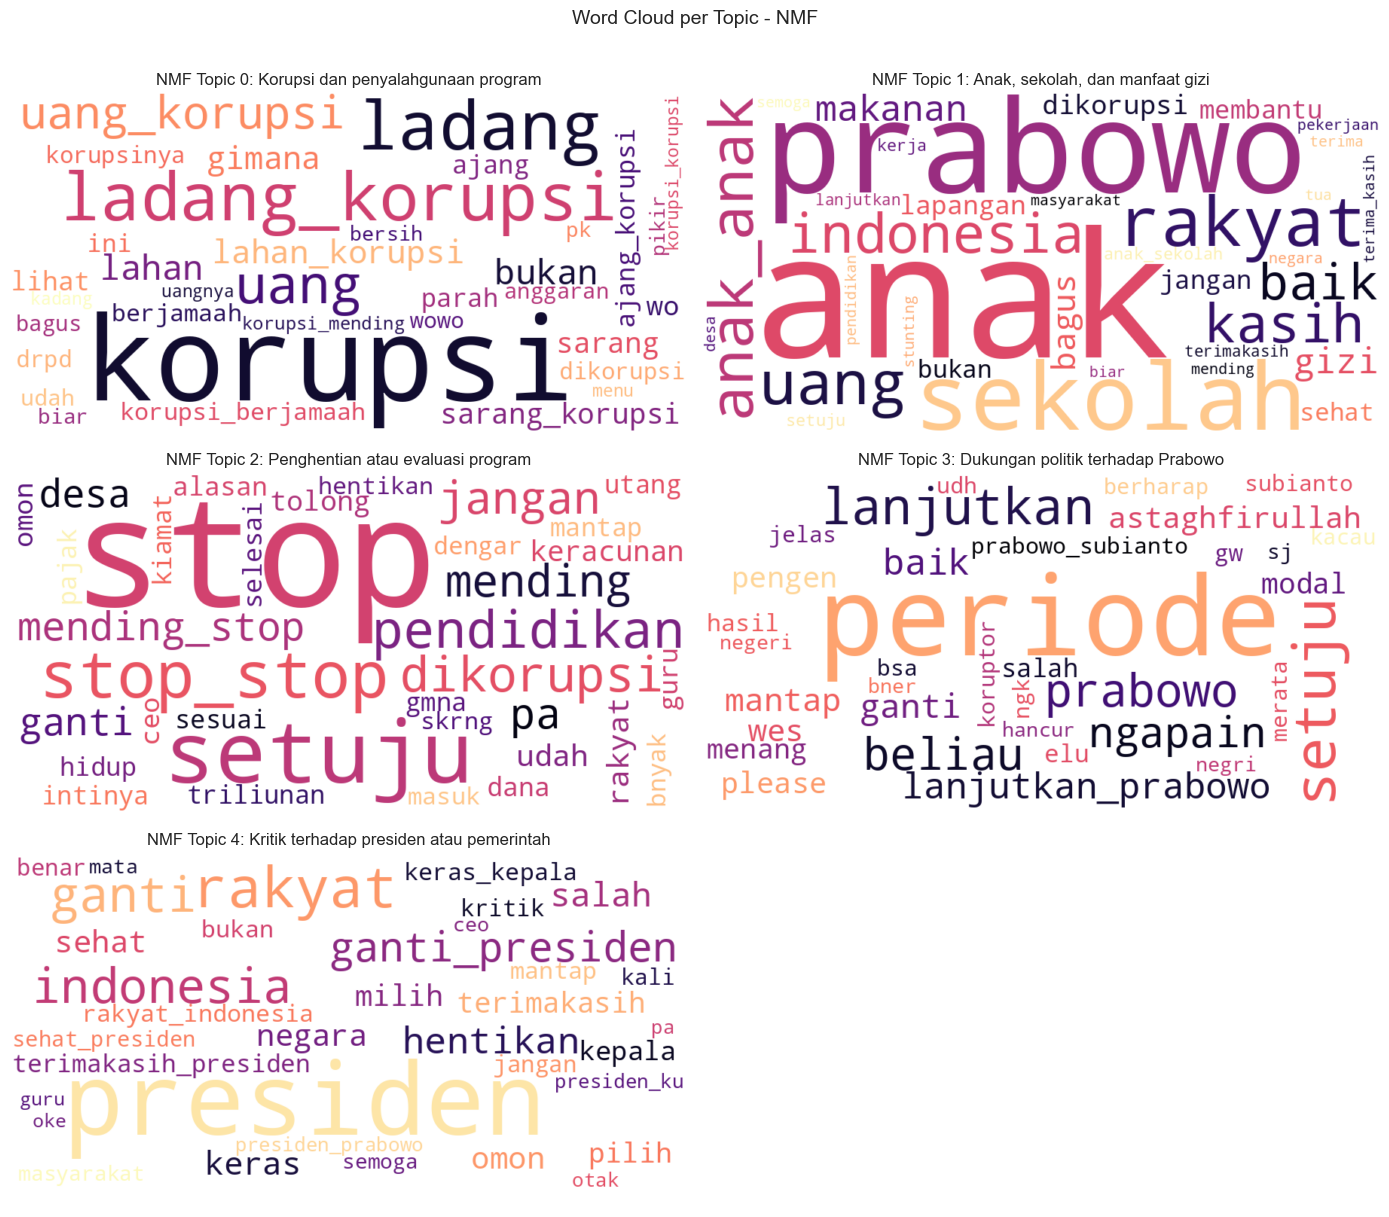

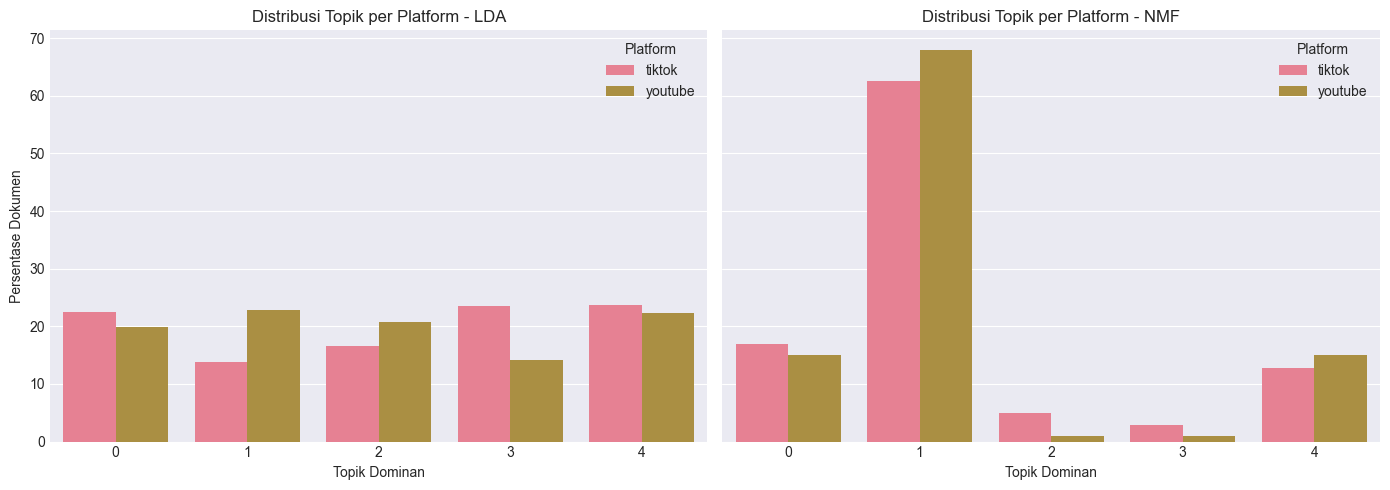

✓ Visualizations created successfully


In [30]:
# Create visualizations for topic modeling results
if 'df_topics' in locals() and 'df_doc_topics' in locals():
    # Load models for visualization
    models_dir = data_dir / "topic_modeling" / "models"
    required_model_files = [
        models_dir / "lda.pkl",
        models_dir / "nmf.pkl",
        models_dir / "count_vectorizer.pkl",
        models_dir / "tfidf_vectorizer.pkl",
    ]
    
    if models_dir.exists() and all(file.exists() for file in required_model_files):
        with open(models_dir / "lda.pkl", "rb") as f:
            lda = pickle.load(f)
        with open(models_dir / "nmf.pkl", "rb") as f:
            nmf = pickle.load(f)
        with open(models_dir / "count_vectorizer.pkl", "rb") as f:
            count_vectorizer = pickle.load(f)
        with open(models_dir / "tfidf_vectorizer.pkl", "rb") as f:
            tfidf_vectorizer = pickle.load(f)
        
        count_features = np.array(count_vectorizer.get_feature_names_out())
        tfidf_features = np.array(tfidf_vectorizer.get_feature_names_out())
        
        def annotate_bars(ax, labels=None, value_format='{:.1f}', suffix=''):
            for index, patch in enumerate(ax.patches):
                height = patch.get_height()
                if not np.isfinite(height):
                    continue
                label = labels[index] if labels is not None and index < len(labels) else f'{value_format.format(height)}{suffix}'
                ax.text(
                    patch.get_x() + patch.get_width() / 2,
                    height,
                    label,
                    ha='center',
                    va='bottom',
                    fontsize=9,
                )

        def get_topic_word_weights(model, feature_names, topic_idx, top_n):
            weights = model.components_[topic_idx]
            top_indices = weights.argsort()[::-1][:top_n]
            return [(feature_names[index], float(weights[index])) for index in top_indices]

        def get_topic_label(model_name, topic_idx):
            label_row = df_topics[
                (df_topics['model'] == model_name.lower())
                & (df_topics['topic_id'].astype(int) == topic_idx)
            ]
            if label_row.empty:
                return f"Topic {topic_idx}"
            return label_row['topic_label'].iloc[0]

        def plot_model_top_words(model, feature_names, model_name, color, top_n=N_WORDS):
            n_topics = min(N_TOPICS, model.components_.shape[0])
            fig, axes = plt.subplots(n_topics, 1, figsize=(12, 3 * n_topics))
            if n_topics == 1:
                axes = [axes]

            for topic_idx, ax in enumerate(axes):
                topic_words = get_topic_word_weights(model, feature_names, topic_idx, top_n)
                words = [word for word, _ in topic_words][::-1]
                values = [value for _, value in topic_words][::-1]
                topic_label = get_topic_label(model_name, topic_idx)

                sns.barplot(x=values, y=words, ax=ax, color=color)
                ax.set_title(f"{model_name.upper()} Topic {topic_idx}: {topic_label}")
                ax.set_xlabel("Weight")
                ax.set_ylabel("")

            fig.suptitle(f"Top Words per Topic - {model_name.upper()}", fontsize=14, y=1.01)
            plt.tight_layout()
            plt.show()

        def plot_wordcloud_fallback(ax, frequencies, title, color):
            ax.set_title(title)
            ax.axis("off")
            words = sorted(frequencies.items(), key=lambda item: item[1], reverse=True)[:30]
            if not words:
                ax.text(0.5, 0.5, "No words", ha="center", va="center", fontsize=12)
                return

            max_weight = max(weight for _, weight in words)
            positions = [(x, y) for y in np.linspace(0.15, 0.85, 4) for x in np.linspace(0.12, 0.88, 6)]
            rng = np.random.default_rng(sum(ord(char) for char in title))
            rng.shuffle(positions)

            for (word, weight), (x_pos, y_pos) in zip(words, positions):
                font_size = 9 + (weight / max_weight) * 24
                rotation = int(rng.choice([-15, 0, 0, 15]))
                ax.text(
                    x_pos,
                    y_pos,
                    word,
                    color=color,
                    fontsize=font_size,
                    fontweight="bold" if weight == max_weight else "normal",
                    ha="center",
                    va="center",
                    rotation=rotation,
                    alpha=0.85,
                    transform=ax.transAxes,
                )

        def plot_model_wordclouds(model, feature_names, model_name, color, max_words=35):
            n_topics = min(N_TOPICS, model.components_.shape[0])
            n_cols = 2
            n_rows = int(np.ceil(n_topics / n_cols))
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
            axes = np.array(axes).reshape(-1)

            for topic_idx, ax in enumerate(axes):
                if topic_idx >= n_topics:
                    ax.axis("off")
                    continue

                topic_words = get_topic_word_weights(model, feature_names, topic_idx, max_words)
                frequencies = {word.replace(" ", "_"): value for word, value in topic_words if value > 0}
                title = f"{model_name.upper()} Topic {topic_idx}: {get_topic_label(model_name, topic_idx)}"

                if WordCloud is not None:
                    wordcloud = WordCloud(
                        width=900,
                        height=450,
                        background_color="white",
                        max_words=max_words,
                        collocations=False,
                        prefer_horizontal=0.9,
                        random_state=RANDOM_STATE + topic_idx,
                        colormap="viridis" if model_name.lower() == "lda" else "magma",
                    ).generate_from_frequencies(frequencies)
                    ax.imshow(wordcloud, interpolation="bilinear")
                    ax.set_title(title)
                    ax.axis("off")
                else:
                    plot_wordcloud_fallback(ax, frequencies, title, color)

            fig.suptitle(f"Word Cloud per Topic - {model_name.upper()}", fontsize=14, y=1.01)
            plt.tight_layout()
            plt.show()
        
        # Distribusi platform: TikTok vs YouTube
        if 'source' in df_doc_topics.columns:
            if 'df_raw' in locals() and 'source' in df_raw.columns:
                platform_counts = df_raw['source'].value_counts().rename_axis('platform').reset_index(name='count')
            else:
                first_model = sorted(df_doc_topics['model'].unique())[0]
                platform_base = df_doc_topics[df_doc_topics['model'] == first_model]
                platform_counts = platform_base['source'].value_counts().rename_axis('platform').reset_index(name='count')
            platform_counts['percentage'] = platform_counts['count'] / platform_counts['count'].sum() * 100
            
            fig, ax = plt.subplots(figsize=(8, 5))
            sns.barplot(data=platform_counts, x='platform', y='count', hue='platform', ax=ax, palette=['#FF6B6B', '#4ECDC4'], legend=False)
            ax.set_title('Distribusi Platform: TikTok vs YouTube')
            ax.set_xlabel('Platform')
            ax.set_ylabel('Jumlah Komentar')
            ax.set_ylim(0, platform_counts['count'].max() * 1.15)
            labels = [f'{row.count:,}\n({row.percentage:.1f}%)' for row in platform_counts.itertuples()]
            annotate_bars(ax, labels=labels)
            plt.tight_layout()
            plt.show()
        
        # Distribusi topik per model
        topic_counts = df_doc_topics.groupby(['model', 'dominant_topic']).size().reset_index(name='count')
        topic_counts['dominant_topic'] = topic_counts['dominant_topic'].astype(int)
        topic_totals = topic_counts.groupby('model')['count'].transform('sum')
        topic_counts['percentage'] = topic_counts['count'] / topic_totals * 100
        
        models = sorted(topic_counts['model'].unique())
        fig, axes = plt.subplots(1, len(models), figsize=(7.5 * len(models), 5), sharey=True)
        if len(models) == 1:
            axes = [axes]
        for ax, model_name in zip(axes, models):
            model_topic_counts = topic_counts[topic_counts['model'] == model_name]
            sns.barplot(data=model_topic_counts, x='dominant_topic', y='percentage', ax=ax, color='#2f6f73' if model_name == 'lda' else '#e76f51')
            ax.set_title(f'Distribusi Topik - {model_name.upper()}')
            ax.set_xlabel('Topik Dominan')
            ax.set_ylabel('Persentase Dokumen')
            ax.set_ylim(0, max(topic_counts['percentage'].max() * 1.15, 5))
            annotate_bars(ax, suffix='%')
        plt.tight_layout()
        plt.show()
        
        # Perbandingan coherence dan diversity
        metrics_file = data_dir / "topic_modeling" / "metrics.csv"
        if metrics_file.exists():
            df_metrics = pd.read_csv(metrics_file)
            metric_columns = ['topic_coherence_npmi', 'topic_diversity']
            metric_labels = {
                'topic_coherence_npmi': 'Coherence (NPMI)',
                'topic_diversity': 'Diversity'
            }
            metrics_long = df_metrics.melt(id_vars='model', value_vars=metric_columns, var_name='metric', value_name='score')
            metrics_long['metric'] = metrics_long['metric'].map(metric_labels)
            
            fig, ax = plt.subplots(figsize=(9, 5))
            sns.barplot(data=metrics_long, x='model', y='score', hue='metric', ax=ax, palette=['#457B9D', '#F4A261'])
            ax.set_title('Perbandingan Coherence & Diversity')
            ax.set_xlabel('Model')
            ax.set_ylabel('Skor')
            ax.set_ylim(0, max(metrics_long['score'].max() * 1.2, 0.1))
            ax.legend(title='Metrik')
            annotate_bars(ax, value_format='{:.3f}')
            plt.tight_layout()
            plt.show()
        else:
            print('Metrics file not found. Run the evaluation cell to create coherence and diversity metrics.')
        
        # Top words untuk kedua topic modeling
        plot_model_top_words(lda, count_features, "lda", "#2f6f73")
        plot_model_top_words(nmf, tfidf_features, "nmf", "#e76f51")

        # Word cloud untuk kedua topic modeling
        plot_model_wordclouds(lda, count_features, "lda", "#2f6f73")
        plot_model_wordclouds(nmf, tfidf_features, "nmf", "#e76f51")
        
        # Distribusi topik per platform untuk kedua topic modeling
        if 'source' in df_doc_topics.columns:
            platform_dist = df_doc_topics.groupby(['model', 'source', 'dominant_topic']).size().reset_index(name='count')
            totals = platform_dist.groupby(['model', 'source'])['count'].transform('sum')
            platform_dist['percentage'] = (platform_dist['count'] / totals * 100).round(2)
            
            models = sorted(platform_dist['model'].unique())
            fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5), sharey=True)
            if len(models) == 1:
                axes = [axes]
            
            for ax, model_name in zip(axes, models):
                model_data = platform_dist[platform_dist['model'] == model_name].copy()
                model_data['dominant_topic'] = model_data['dominant_topic'].astype(int)
                sns.barplot(data=model_data, x='dominant_topic', y='percentage', hue='source', ax=ax)
                ax.set_title(f"Distribusi Topik per Platform - {model_name.upper()}")
                ax.set_xlabel("Topik Dominan")
                ax.set_ylabel("Persentase Dokumen")
                ax.legend(title="Platform")
            
            plt.tight_layout()
            plt.show()
        
        print("✓ Visualizations created successfully")
    else:
        print("✗ Model files not found. Please run topic modeling first.")
else:
    print("✗ Topic results not loaded. Please load topic results first.")

### Tabel Top Words

Tabel ini menampilkan 10 kata teratas untuk masing-masing topik pada model LDA dan NMF.

In [20]:
if 'df_topics' in locals():
    TOP_WORDS_TABLE_LIMIT = 10

    def create_top_words_table(df_topics, model_name, top_n=10):
        model_topics = df_topics[df_topics['model'] == model_name].copy()
        word_columns = [f'word_{idx}' for idx in range(1, top_n + 1)]

        top_words = (
            model_topics['top_words']
            .fillna('')
            .str.split(',', expand=True)
            .iloc[:, :top_n]
            .apply(lambda col: col.str.strip())
        )
        top_words = top_words.reindex(columns=range(top_n), fill_value='')
        top_words.columns = word_columns

        return pd.concat(
            [model_topics[['topic_id', 'topic_label']].reset_index(drop=True), top_words.reset_index(drop=True)],
            axis=1,
        )

    lda_top_words_table = create_top_words_table(df_topics, 'lda', TOP_WORDS_TABLE_LIMIT)
    nmf_top_words_table = create_top_words_table(df_topics, 'nmf', TOP_WORDS_TABLE_LIMIT)

    print("LDA Top Words Table")
    display(lda_top_words_table)

    print("NMF Top Words Table")
    display(nmf_top_words_table)
else:
    print("Topic results not loaded. Please load topic results first.")

LDA Top Words Table


,topic_id,topic_label,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,word_10
0,0,Penghentian atau evaluasi program,rakyat,negara,stop,anggaran,benar,uang,presiden,bagus,jangan,bukan
1,1,"Anak, sekolah, dan manfaat gizi",anak,baik,lapangan,indonesia,presiden,prabowo,masyarakat,kasih,gizi,sehat
2,2,"Anak, sekolah, dan manfaat gizi",anak,sekolah,prabowo,desa,daerah,stunting,anak anak,ekonomi,makanan,lanjutkan
3,3,"Implementasi dapur, menu, dan sekolah",dikorupsi,sekolah,setuju,menu,guru,dana,uang,dapur,mending,langsung
4,4,Korupsi dan penyalahgunaan program,korupsi,presiden,ladang,periode,jangan,kepala,uang,ladang korupsi,keras,bagus


NMF Top Words Table


,topic_id,topic_label,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,word_10
0,0,Korupsi dan penyalahgunaan program,korupsi,ladang,ladang korupsi,uang,uang korupsi,lahan,bukan,lahan korupsi,gimana,sarang korupsi
1,1,"Anak, sekolah, dan manfaat gizi",anak,prabowo,sekolah,rakyat,uang,anak anak,indonesia,kasih,baik,makanan
2,2,Penghentian atau evaluasi program,stop,setuju,stop stop,pendidikan,dikorupsi,jangan,mending,pa,mending stop,ganti
3,3,Dukungan politik terhadap Prabowo,periode,setuju,lanjutkan,prabowo,beliau,ngapain,baik,lanjutkan prabowo,ganti,mantap
4,4,Kritik terhadap presiden atau pemerintah,presiden,rakyat,ganti,indonesia,ganti presiden,hentikan,salah,keras,omon,sehat


## 6. Evaluation

Evaluate the topic models using coherence, diversity, and other metrics.

In [19]:
# Run evaluation pipeline
evaluator = TopicModelEvaluator(data_dir=str(data_dir))

print("Running evaluation pipeline...")
print("=" * 50)

try:
    eval_results = evaluator.run(n_topics=N_TOPICS, n_words=N_WORDS)
    print("\n")
    print("✓ Evaluation completed successfully")
    print(f"✓ Records evaluated: {eval_results['records']}")
    print(f"✓ Metrics saved to: {eval_results['metrics_file']}")
    print(f"✓ Summary saved to: {eval_results['summary_file']}")
    
    # Load and display metrics
    metrics_file = data_dir / "topic_modeling" / "metrics.csv"
    if metrics_file.exists():
        df_metrics = pd.read_csv(metrics_file)
        print("\n" + "=" * 50)
        print("Model Comparison Metrics:")
        print("=" * 50)
        print(df_metrics.to_string(index=False))
        
        # Determine best model
        best_model = df_metrics.sort_values(
            ['topic_coherence_npmi', 'topic_diversity'], 
            ascending=False
        ).iloc[0]
        print(f"\n✓ Best model: {best_model['model'].upper()}")
        print(f"  Coherence NPMI: {best_model['topic_coherence_npmi']:.4f}")
        print(f"  Topic Diversity: {best_model['topic_diversity']:.4f}")
    
    # Load and display summary
    summary_file = data_dir / "topic_modeling" / "summary.md"
    if summary_file.exists():
        print("\n" + "=" * 50)
        print("Evaluation Summary:")
        print("=" * 50)
        print(summary_file.read_text(encoding='utf-8'))
        
except Exception as e:
    print(f"✗ Error during evaluation: {e}")
    print("Please ensure topic modeling results exist in data/topic_modeling/")

2026-06-18 17:53:00,067 - INFO - Loaded 3611 records from d:\python\stance-classification\data\preprocessed\comments_processed_5.csv
2026-06-18 17:53:00,070 - INFO - Using 3611 non-empty comments for evaluation
2026-06-18 17:53:00,071 - INFO - Source distribution: {'tiktok': 2694, 'youtube': 917}
2026-06-18 17:53:00,072 - INFO - Loaded topics from d:\python\stance-classification\data\topic_modeling\topics.csv
2026-06-18 17:53:00,086 - INFO - Loaded document topics from d:\python\stance-classification\data\topic_modeling\document_topics.csv
2026-06-18 17:53:00,088 - INFO - Loaded models and vectorizers
2026-06-18 17:53:00,163 - INFO - Topic diversity: {'lda': 0.82, 'nmf': 0.84}
2026-06-18 17:53:00,178 - INFO - Topic coherence: {'lda': 0.1256400898629856, 'nmf': 0.0}
2026-06-18 17:53:00,188 - INFO - Topic coherence: {'lda': 0.0, 'nmf': 0.1690952987649315}
2026-06-18 17:53:00,198 - INFO - Saved topic size to d:\python\stance-classification\data\topic_modeling\topic_size.csv
2026-06-18 17:

Running evaluation pipeline...


2026-06-18 17:53:00,814 - INFO - Saved plot: d:\python\stance-classification\data\topic_modeling\plots\lda_top_words.png
2026-06-18 17:53:01,281 - INFO - Saved plot: d:\python\stance-classification\data\topic_modeling\plots\nmf_top_words.png
2026-06-18 17:53:01,490 - INFO - Saved plot: d:\python\stance-classification\data\topic_modeling\plots\platform_topic_distribution.png
2026-06-18 17:53:01,583 - INFO - Saved plot: d:\python\stance-classification\data\topic_modeling\plots\lda_topic_size.png
2026-06-18 17:53:01,658 - INFO - Saved plot: d:\python\stance-classification\data\topic_modeling\plots\nmf_topic_size.png
2026-06-18 17:53:01,667 - INFO - Saved summary: d:\python\stance-classification\data\topic_modeling\summary.md
2026-06-18 17:53:01,668 - INFO - Evaluation completed successfully



✓ Evaluation completed successfully
✓ Records evaluated: 3611
✓ Metrics saved to: d:\python\stance-classification\data\topic_modeling\metrics.csv
✓ Summary saved to: d:\python\stance-classification\data\topic_modeling\summary.md

Model Comparison Metrics:
model  n_topics  topic_coherence_npmi  topic_diversity
  lda         5              0.125640             0.82
  nmf         5              0.169095             0.84

✓ Best model: NMF
  Coherence NPMI: 0.1691
  Topic Diversity: 0.8400

Evaluation Summary:
# Topic Modeling Evaluation Summary

## Dataset

- Total komentar digunakan: 3611
- TikTok: 2694
- YouTube: 917

## Model Comparison

| Model | Topics | Coherence NPMI | Topic Diversity |
| --- | ---: | ---: | ---: |
| LDA | 5 | 0.1256 | 0.8200 |
| NMF | 5 | 0.1691 | 0.8400 |

## Recommendation

Model terbaik pada konfigurasi ini adalah NMF karena memiliki coherence NPMI 0.1691 dan topic diversity 0.8400.

## Topics

### LDA

- Topic 0 (Penghentian atau evaluasi program): rakyat, ne

## 7. Summary & Next Steps

### Pipeline Execution Summary

This notebook provides a complete wrapper for the stance classification pipeline:

1. **Data Collection** - Uses existing scrapped data from TikTok and YouTube
2. **EDA & Data Loading** - Explores and analyzes raw data
3. **Preprocessing** - Cleans, normalizes, and filters text data
4. **Topic Modeling** - Applies LDA and NMF for topic discovery
5. **Visualization** - Creates visualizations for topics and data
6. **Evaluation** - Evaluates models using coherence and diversity metrics

### Output Files

All outputs are saved in the `data/` directory:
- `data/scrapped/` - Raw scraped data
- `data/preprocessed/` - Cleaned and processed data
- `data/topic_modeling/` - Topic models and results
  - `topics.csv` - Top words per topic
  - `document_topics.csv` - Topic assignments per document
  - `metrics.csv` - Model evaluation metrics
  - `summary.md` - Evaluation summary
  - `plots/` - Visualization files

### Next Steps

- **Labeling Preparation** - Use `03_prepare_labeling.py` to prepare data for manual labeling
- **Fine-tuning** - Use `04_finetuning_bert.py` to train stance classification models
- **Advanced Analysis** - Explore topic distributions across different time periods or engagement metrics

### Customization

You can customize the pipeline by modifying:
- `N_TOPICS` - Number of topics for modeling
- `N_WORDS` - Number of top words to display per topic
- Preprocessing parameters in the preprocessing cells
- Visualization styles and parameters